In [2]:
import ipaddress
import pandas as pd
import matplotlib.pyplot as plt

# Matches the offset used in modbus_specific.ipynb
TIME_OFFSET = 10800

In [3]:
def _prepare_src_window_df(
    input_csv,
    src_ip,
    center_timestamp,
    interval_seconds,
    time_offset_seconds=TIME_OFFSET,
):
    """
    Build a 1-second binned dataframe for packets sent by src_ip in
    [center_timestamp - interval_seconds, center_timestamp + interval_seconds].
    """
    ipaddress.ip_address(src_ip)

    df = pd.read_csv(input_csv)

    required_cols = {"ip.src", "ip.dst", "frame.time_epoch"}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required column(s): {sorted(missing)}")

    frame_epoch = pd.to_numeric(df["frame.time_epoch"], errors="coerce")
    df = df.loc[frame_epoch.notna()].copy()
    df["aligned_ts"] = pd.to_datetime(
        frame_epoch[frame_epoch.notna()] + float(time_offset_seconds),
        unit="s",
        errors="coerce",
    )

    center_ts = pd.to_datetime(center_timestamp, errors="raise")
    start_ts = center_ts - pd.Timedelta(seconds=int(interval_seconds))
    end_ts = center_ts + pd.Timedelta(seconds=int(interval_seconds))

    src_df = df[df["ip.src"].astype(str) == src_ip].copy()
    window_df = src_df[(src_df["aligned_ts"] >= start_ts) & (src_df["aligned_ts"] <= end_ts)].copy()

    window_df["second_bin"] = window_df["aligned_ts"].dt.floor("s")
    center_second = center_ts.floor("s")
    plot_bins = pd.date_range(
        start=center_second - pd.Timedelta(seconds=int(interval_seconds)),
        end=center_second + pd.Timedelta(seconds=int(interval_seconds)),
        freq="s",
    )
    rel_x = (plot_bins - center_second).total_seconds().astype(int)

    return window_df, plot_bins, rel_x, center_ts


def _plot_series(rel_x, values, ylabel, title):
    plt.figure(figsize=(11, 4))
    plt.plot(rel_x, values, marker="o")
    plt.axvline(0, color="black", linestyle="--", linewidth=1, label="Target timestamp")
    plt.xlabel("Seconds offset from target timestamp")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_unique_dst_ips(
    input_csv,
    src_ip,
    center_timestamp,
    interval_seconds,
    time_offset_seconds=TIME_OFFSET,
):
    """1) Plot number of unique destination IPs per 1-second bin for a given src_ip."""
    window_df, plot_bins, rel_x, center_ts = _prepare_src_window_df(
        input_csv,
        src_ip,
        center_timestamp,
        interval_seconds,
        time_offset_seconds,
    )

    series = (
        window_df.groupby("second_bin")["ip.dst"]
        .nunique()
        .reindex(plot_bins, fill_value=0)
    )

    _plot_series(
        rel_x,
        series.values,
        ylabel="nunique(ip.dst)",
        title=f"Unique dst IPs for src={src_ip} around {center_ts} (±{interval_seconds}s)",
    )
    return series


def plot_nunique_unit_id(
    input_csv,
    src_ip,
    center_timestamp,
    interval_seconds,
    unit_id_col="mbtcp.unit_id",
    time_offset_seconds=TIME_OFFSET,
):
    """2) Plot nunique(mbtcp.unit_id) per 1-second bin for a given src_ip."""
    window_df, plot_bins, rel_x, center_ts = _prepare_src_window_df(
        input_csv,
        src_ip,
        center_timestamp,
        interval_seconds,
        time_offset_seconds,
    )

    if unit_id_col not in window_df.columns:
        raise ValueError(f"Column not found: {unit_id_col}")

    series = (
        window_df.groupby("second_bin")[unit_id_col]
        .nunique()
        .reindex(plot_bins, fill_value=0)
    )

    _plot_series(
        rel_x,
        series.values,
        ylabel=f"nunique({unit_id_col})",
        title=f"Unique unit_id for src={src_ip} around {center_ts} (±{interval_seconds}s)",
    )
    return series


def plot_nunique_func_code(
    input_csv,
    src_ip,
    center_timestamp,
    interval_seconds,
    func_col="modbus.func_code",
    time_offset_seconds=TIME_OFFSET,
):
    """3) Plot nunique(modbus.func_code) per 1-second bin for a given src_ip."""
    window_df, plot_bins, rel_x, center_ts = _prepare_src_window_df(
        input_csv,
        src_ip,
        center_timestamp,
        interval_seconds,
        time_offset_seconds,
    )

    if func_col not in window_df.columns:
        raise ValueError(f"Column not found: {func_col}")

    series = (
        window_df.groupby("second_bin")[func_col]
        .nunique()
        .reindex(plot_bins, fill_value=0)
    )

    _plot_series(
        rel_x,
        series.values,
        ylabel=f"nunique({func_col})",
        title=f"Unique function codes for src={src_ip} around {center_ts} (±{interval_seconds}s)",
    )
    return series


def plot_packet_count(
    input_csv,
    src_ip,
    center_timestamp,
    interval_seconds,
    time_offset_seconds=TIME_OFFSET,
):
    """4) Plot packet_count per 1-second bin for a given src_ip."""
    window_df, plot_bins, rel_x, center_ts = _prepare_src_window_df(
        input_csv,
        src_ip,
        center_timestamp,
        interval_seconds,
        time_offset_seconds,
    )

    series = (
        window_df.groupby("second_bin")
        .size()
        .reindex(plot_bins, fill_value=0)
    )

    _plot_series(
        rel_x,
        series.values,
        ylabel="packet_count",
        title=f"Packet count for src={src_ip} around {center_ts} (±{interval_seconds}s)",
    )
    return series


# Example usage:
# input_csv = "../train/cscada_attack_ssw.csv"
# src_ip = "185.175.0.5"
# center_timestamp = "2023-03-19 03:01:57.813"
# x = 20
#
# plot_unique_dst_ips(input_csv, src_ip, center_timestamp, x)
# plot_nunique_unit_id(input_csv, src_ip, center_timestamp, x)
# plot_nunique_func_code(input_csv, src_ip, center_timestamp, x)
# plot_packet_count(input_csv, src_ip, center_timestamp, x)

/tmp/ipykernel_439336/32164815.py:14: DtypeWarning: Columns (0: mbtcp.trans_id, 1: mbtcp.unit_id, 2: mbtcp.len, 3: mbtcp.prot_id, 4: modbus.func_code, 5: modbus.reference_num, 6: modbus.regnum16, 7: modbus.bitnum, 8: modbus.word_cnt, 9: modbus.bit_cnt, 10: modbus.regval_uint16, 11: modbus.data) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


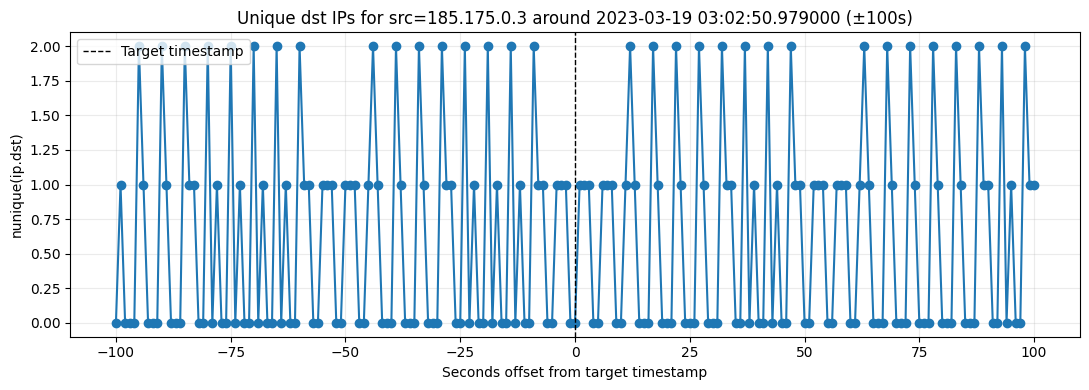

2023-03-19 03:01:10    0
2023-03-19 03:01:11    1
2023-03-19 03:01:12    0
2023-03-19 03:01:13    0
2023-03-19 03:01:14    0
                      ..
2023-03-19 03:04:26    0
2023-03-19 03:04:27    0
2023-03-19 03:04:28    2
2023-03-19 03:04:29    1
2023-03-19 03:04:30    1
Freq: s, Name: ip.dst, Length: 201, dtype: int64

In [16]:
# compromised-scada 
# victims: '185.175.0.5', '185.175.0.4', '185.175.0.8'
# attacker: 185.175.0.3

plot_unique_dst_ips("../train/cscada_attack_ssw_analysis.csv", "185.175.0.3", "2023-03-19 03:02:50.979", 100)

/tmp/ipykernel_439336/32164815.py:14: DtypeWarning: Columns (0: mbtcp.trans_id, 1: mbtcp.unit_id, 2: mbtcp.len, 3: mbtcp.prot_id, 4: modbus.func_code, 5: modbus.reference_num, 6: modbus.regnum16, 7: modbus.bitnum, 8: modbus.word_cnt, 9: modbus.bit_cnt, 10: modbus.regval_uint16, 11: modbus.data) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


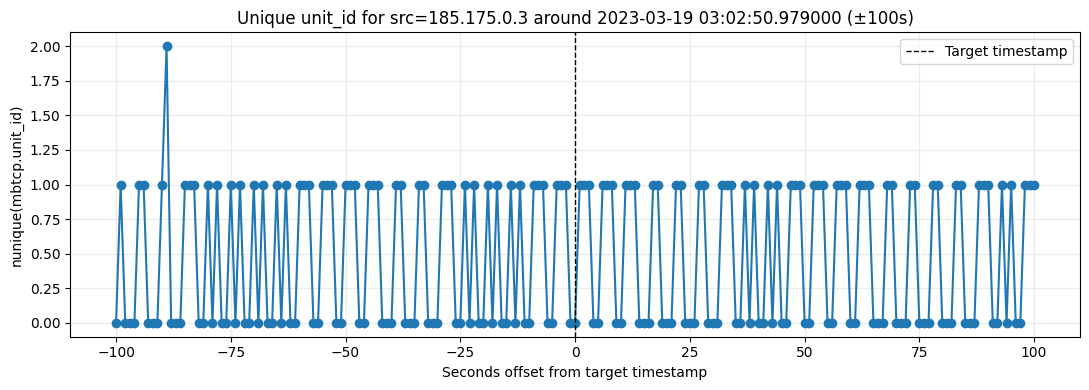

2023-03-19 03:01:10    0
2023-03-19 03:01:11    1
2023-03-19 03:01:12    0
2023-03-19 03:01:13    0
2023-03-19 03:01:14    0
                      ..
2023-03-19 03:04:26    0
2023-03-19 03:04:27    0
2023-03-19 03:04:28    1
2023-03-19 03:04:29    1
2023-03-19 03:04:30    1
Freq: s, Name: mbtcp.unit_id, Length: 201, dtype: int64

In [25]:
plot_nunique_unit_id("../train/cscada_attack_ssw_analysis.csv", "185.175.0.3", "2023-03-19 03:02:50.979", 100)


/tmp/ipykernel_439336/32164815.py:14: DtypeWarning: Columns (0: mbtcp.trans_id, 1: mbtcp.unit_id, 2: mbtcp.len, 3: mbtcp.prot_id, 4: modbus.func_code, 5: modbus.reference_num, 6: modbus.regnum16, 7: modbus.bitnum, 8: modbus.word_cnt, 9: modbus.bit_cnt, 10: modbus.regval_uint16, 11: modbus.data) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


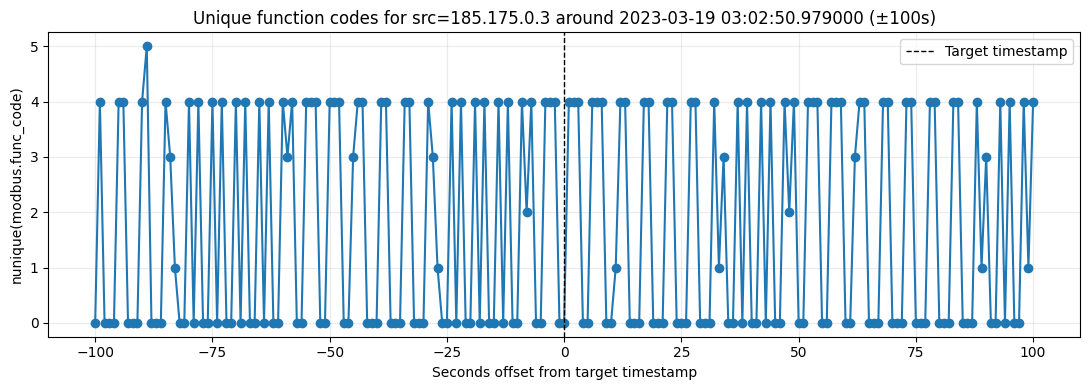

2023-03-19 03:01:10    0
2023-03-19 03:01:11    4
2023-03-19 03:01:12    0
2023-03-19 03:01:13    0
2023-03-19 03:01:14    0
                      ..
2023-03-19 03:04:26    0
2023-03-19 03:04:27    0
2023-03-19 03:04:28    4
2023-03-19 03:04:29    1
2023-03-19 03:04:30    4
Freq: s, Name: modbus.func_code, Length: 201, dtype: int64

In [18]:
plot_nunique_func_code("../train/cscada_attack_ssw_analysis.csv", "185.175.0.3", "2023-03-19 03:02:50.979", 100)

/tmp/ipykernel_439336/32164815.py:14: DtypeWarning: Columns (0: mbtcp.trans_id, 1: mbtcp.unit_id, 2: mbtcp.len, 3: mbtcp.prot_id, 4: modbus.func_code, 5: modbus.reference_num, 6: modbus.regnum16, 7: modbus.bitnum, 8: modbus.word_cnt, 9: modbus.bit_cnt, 10: modbus.regval_uint16, 11: modbus.data) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_csv)


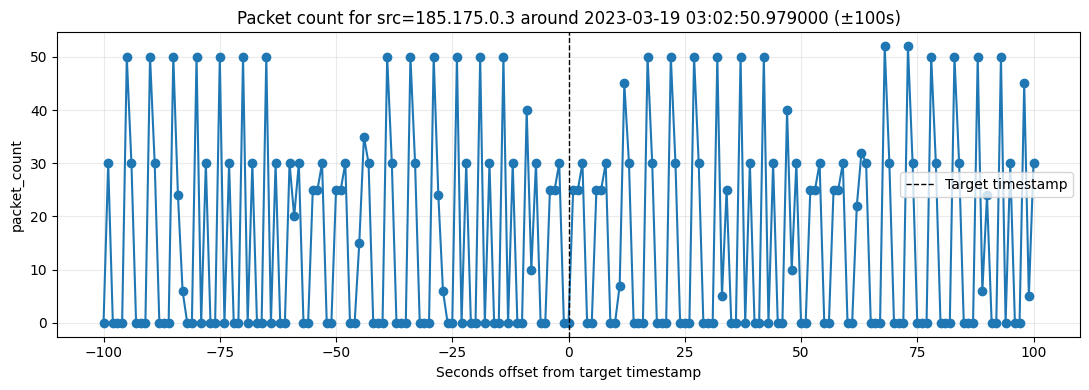

2023-03-19 03:01:10     0
2023-03-19 03:01:11    30
2023-03-19 03:01:12     0
2023-03-19 03:01:13     0
2023-03-19 03:01:14     0
                       ..
2023-03-19 03:04:26     0
2023-03-19 03:04:27     0
2023-03-19 03:04:28    45
2023-03-19 03:04:29     5
2023-03-19 03:04:30    30
Freq: s, Length: 201, dtype: int64

In [19]:
plot_packet_count("../train/cscada_attack_ssw_analysis.csv", "185.175.0.3", "2023-03-19 03:02:50.979", 100)